## Forecasting On Air Passenger data

# Project Pipeline
Load Data
   ↓
Clean & Handle Missing Values
   ↓
Convert Date Index
   ↓
Visualization
   ↓
Stationarity Check
   ↓
Differencing
   ↓
Train/Test Split
   ↓
Model Training (ARIMA)
   ↓
Forecast
   ↓
Evaluation
   ↓
Future Prediction

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import mean_absolute_percentage_error
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load AirPassengers Dataset

In [119]:
df=pd.read_csv(r'C:\Users\anupa\Desktop\Python Learning\Forecasting\AirPassengers.csv')

In [120]:
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [121]:
df.tail()

,Month,Passengers
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


# Convert Month Column

In [123]:
df['Month'] = pd.to_datetime(df['Month'])

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Month       144 non-null    datetime64[ns]
 1   Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [125]:
df.set_index('Month', inplace=True)

# Check Missing Values

In [126]:
df.isnull().sum()

Passengers    0
dtype: int64

In [127]:
df = df.dropna()

# Visualize Time Series

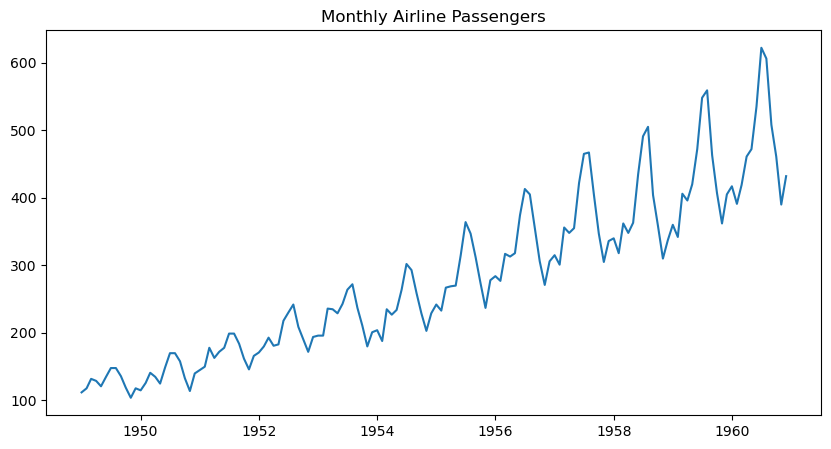

In [128]:
plt.figure(figsize=(10,5))
plt.plot(df)
plt.title("Monthly Airline Passengers")
plt.show()

# Check Stationarity

In [129]:
result = adfuller(df['Passengers'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.8153688792060511
p-value: 0.991880243437641


Interpretation:

p < 0.05 → Stationary

p > 0.05 → Need differencing

# Difference the Series

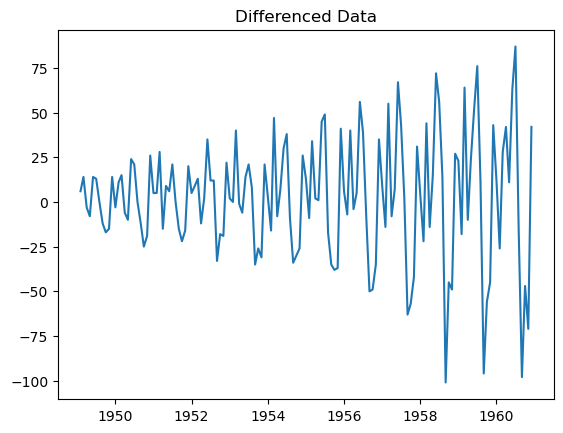

In [130]:
df_diff = df.diff().dropna()
plt.plot(df_diff)
plt.title("Differenced Data")
plt.show()

# Second Stationarity Checking

In [131]:
result = adfuller(df_diff['Passengers'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.8292668241699874
p-value: 0.05421329028382711


# ACF PLot

<Figure size 1000x500 with 0 Axes>

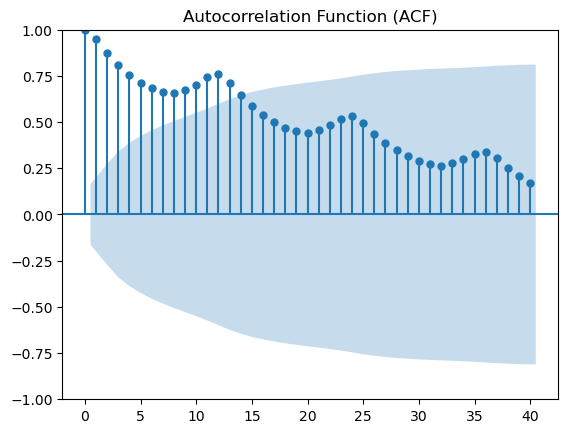

In [132]:
plt.figure(figsize=(10,5))
plot_acf(df['Passengers'], lags=40)
plt.title("Autocorrelation Function (ACF)")
plt.show()

# Pacf Plat

<Figure size 1000x500 with 0 Axes>

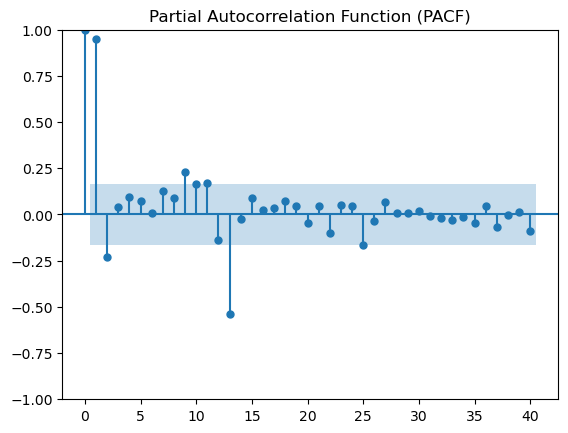

In [133]:
plt.figure(figsize=(10,5))
plot_pacf(df['Passengers'], lags=40)
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

# Train Test Split

In [134]:
train_size = int(len(df) * 0.8)
train = df[:train_size]
test = df[train_size:]

# Build ARIMA Model

In [135]:
model = ARIMA(train['Passengers'], order=(4,1,12))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  115
Model:                ARIMA(4, 1, 12)   Log Likelihood                -476.574
Date:                Thu, 12 Mar 2026   AIC                            987.148
Time:                        13:37:53   BIC                           1033.664
Sample:                    01-01-1949   HQIC                          1006.026
                         - 07-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6633      0.070     23.864      0.000       1.527       1.800
ar.L2         -1.8088      0.127    -14.231      0.000      -2.058      -1.560
ar.L3          1.5601      0.127     12.307      0.0

# Forecast

In [136]:
forecast = model_fit.forecast(steps=len(test))
forecast = pd.Series(forecast, index=test.index)
forecast 

Month
1958-08-01    470.543158
1958-09-01    421.028322
1958-10-01    387.025526
1958-11-01    354.167550
1958-12-01    344.483601
1959-01-01    315.376145
1959-02-01    304.999112
1959-03-01    341.036868
1959-04-01    357.994043
1959-05-01    372.194188
1959-06-01    415.348540
1959-07-01    455.073694
1959-08-01    449.531771
1959-09-01    422.625184
1959-10-01    409.883699
1959-11-01    391.905139
1959-12-01    348.207297
1960-01-01    313.098103
1960-02-01    317.500037
1960-03-01    336.814279
1960-04-01    346.694255
1960-05-01    367.590790
1960-06-01    410.529709
1960-07-01    441.669344
1960-08-01    439.241252
1960-09-01    426.502512
1960-10-01    418.499676
1960-11-01    395.589064
1960-12-01    354.334062
Name: predicted_mean, dtype: float64

# Visualization of Forecast

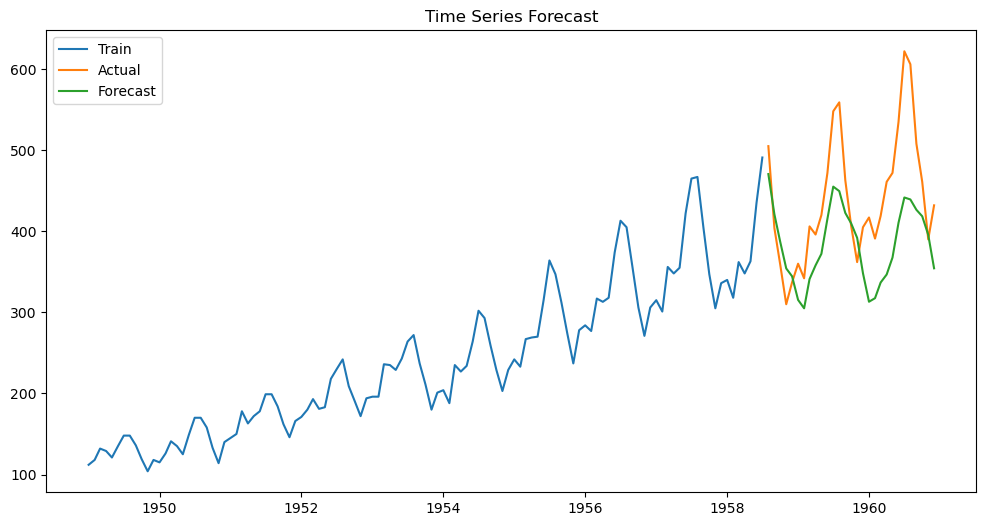

In [137]:
plt.figure(figsize=(12,6))
plt.plot(train, label="Train")
plt.plot(test, label="Actual")
plt.plot(forecast, label="Forecast")
plt.legend()
plt.title("Time Series Forecast")
plt.show()

# Evaluate Model

In [140]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
y_true = test['Passengers']
y_pred = forecast
mape = mean_absolute_percentage_error(y_true, y_pred)
print("MAPE:", mape*100)
print("MAE:", mae)
print("RMSE:", rmse)

MAPE: 14.153692801273564
MAE: 65.85099595444427
RMSE: 79.31109973905562


# Future Forecast

Forecast next 30 days.

In [141]:
future = model_fit.forecast(steps=30)
print(future)

1958-08-01    470.543158
1958-09-01    421.028322
1958-10-01    387.025526
1958-11-01    354.167550
1958-12-01    344.483601
1959-01-01    315.376145
1959-02-01    304.999112
1959-03-01    341.036868
1959-04-01    357.994043
1959-05-01    372.194188
1959-06-01    415.348540
1959-07-01    455.073694
1959-08-01    449.531771
1959-09-01    422.625184
1959-10-01    409.883699
1959-11-01    391.905139
1959-12-01    348.207297
1960-01-01    313.098103
1960-02-01    317.500037
1960-03-01    336.814279
1960-04-01    346.694255
1960-05-01    367.590790
1960-06-01    410.529709
1960-07-01    441.669344
1960-08-01    439.241252
1960-09-01    426.502512
1960-10-01    418.499676
1960-11-01    395.589064
1960-12-01    354.334062
1961-01-01    326.474064
Freq: MS, Name: predicted_mean, dtype: float64


# Plot future prediction:

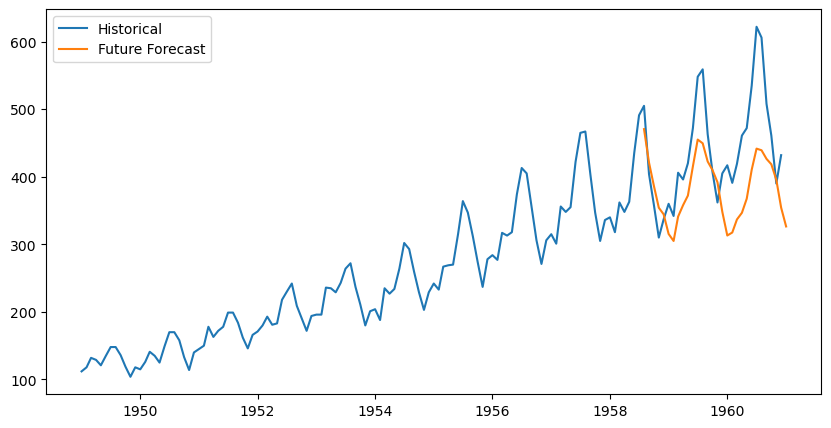

In [142]:
plt.figure(figsize=(10,5))
plt.plot(df, label="Historical")
plt.plot(future, label="Future Forecast")
plt.legend()
plt.show()

## **************Forecasting On WALLMART data*******************

# Project Workflow
1 Data Collection (Walmart Dataset)
        ↓
2 Data Cleaning & Preprocessing
        ↓
3 Exploratory Data Analysis
        ↓
4 Feature Aggregation
        ↓
5 Train/Test Split
        ↓
6 ARIMA Model Training
        ↓
7 Forecasting
        ↓
8 Model Evaluation
        ↓
9 Future Sales Prediction

In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import mean_absolute_percentage_error
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load Dataset

In [144]:
df_1=pd.read_csv(r'C:\Users\anupa\Desktop\Python Learning\Forecasting\train.csv')

In [145]:
df_1.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


# Data Preprocessing
Convert Date column to datetime.

In [146]:
df_1['Date'] = pd.to_datetime(df_1['Date'])

In [147]:
df_1 =df_1.sort_values('Date')

In [238]:
df_1 = df_1[df_1["Weekly_Sales"] > 0]

# Aggregate Weekly Sales

In [239]:
sales = df_1.groupby('Date')['Weekly_Sales'].sum().reset_index()
sales.head()

,Date,Weekly_Sales
0,2010-02-05,49750875.98
1,2010-02-12,48336800.10
2,2010-02-19,48277902.33
3,2010-02-26,43970440.65
4,2010-03-05,46872715.16


In [240]:
sales.set_index('Date', inplace=True)

# Exploratory Data Analysis

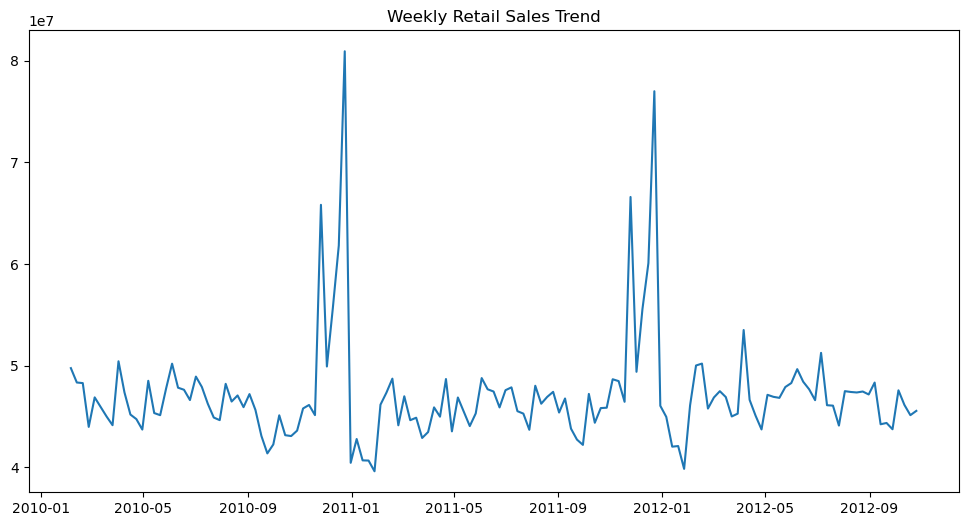

In [241]:
plt.figure(figsize=(12,6))
plt.plot(sales)
plt.title("Weekly Retail Sales Trend")
plt.show()

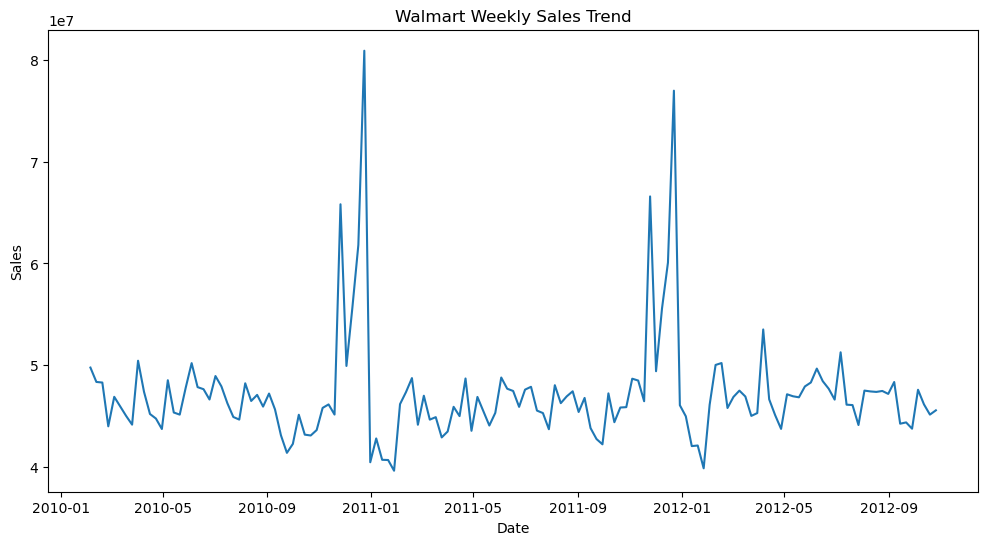

In [242]:
plt.figure(figsize=(12,6))
plt.plot(sales)
plt.title("Walmart Weekly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# Check Stationarity

In [243]:
result = adfuller(sales['Weekly_Sales'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -5.9083977177974365
p-value: 2.67460678882577e-07


# Difference the series

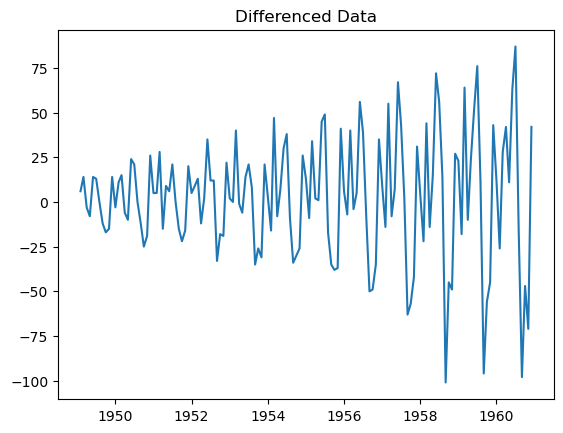

In [244]:
sales_diff =  sales.diff().dropna()
plt.plot(df_diff)
plt.title("Differenced Data")
plt.show()

# Second Stationarity Checking

In [245]:
result = adfuller(sales_diff['Weekly_Sales'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -6.69952805865287
p-value: 3.9213088895704494e-09


# Train Test Split

In [246]:
train_size = int(len(sales)*0.8)
train = sales[:train_size]
test = sales[train_size:]

# ACF Plot

<Figure size 1000x500 with 0 Axes>

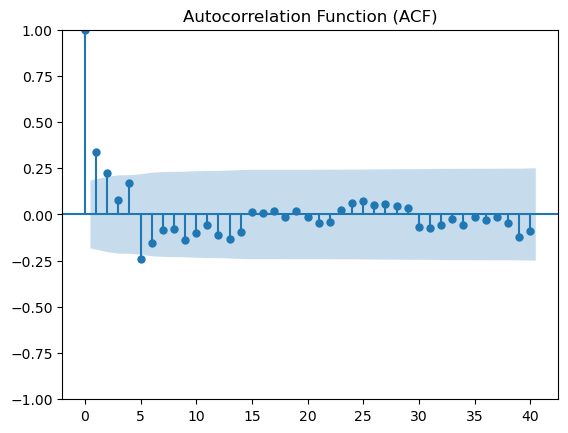

In [247]:
plt.figure(figsize=(10,5))
plot_acf(train['Weekly_Sales'], lags=40)
plt.title("Autocorrelation Function (ACF)")
plt.show()

# PACF Plot

<Figure size 1000x500 with 0 Axes>

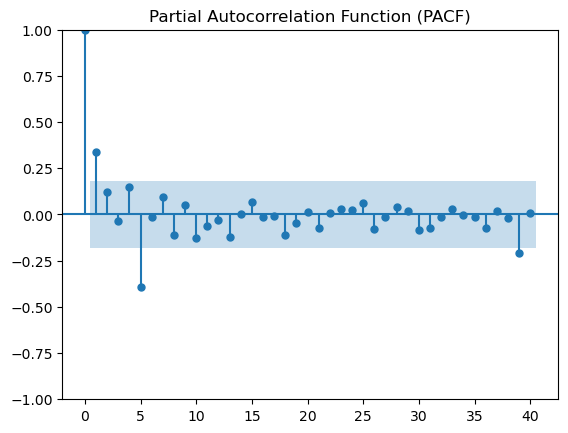

In [248]:
plt.figure(figsize=(10,5))
plot_pacf(train['Weekly_Sales'], lags=40)
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

# Build ARIMA Model

In [249]:
model = ARIMA(train['Weekly_Sales'], order=(3,0,2))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                  114
Model:                 ARIMA(3, 0, 2)   Log Likelihood               -1929.168
Date:                Thu, 12 Mar 2026   AIC                           3872.335
Time:                        14:16:13   BIC                           3891.489
Sample:                    02-05-2010   HQIC                          3880.108
                         - 04-06-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.722e+07   3.13e+05    151.044      0.000    4.66e+07    4.78e+07
ar.L1          0.5720      0.269      2.127      0.033       0.045       1.099
ar.L2          0.7399      0.302      2.447      0.0

# Forecast Test Data

In [250]:
forecast = model_fit.forecast(steps=len(test))
forecast = pd.Series(forecast, index=test.index)
print("Test length:", len(test))
print("Forecast length:", len(forecast))

Test length: 29
Forecast length: 29


# Visualization

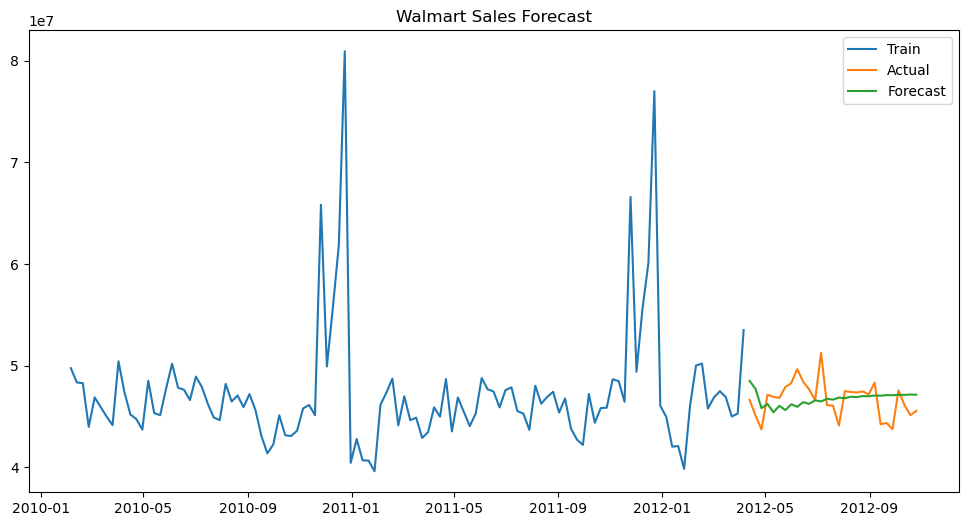

In [251]:
plt.figure(figsize=(12,6))
plt.plot(train, label="Train")
plt.plot(test, label="Actual")
plt.plot(forecast, label="Forecast")
plt.legend()
plt.title("Walmart Sales Forecast")
plt.show()

# Model Evaluation

In [252]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
y_true = test['Weekly_Sales']
y_pred = forecast
mape = mean_absolute_percentage_error(y_true, y_pred)
print("MAPE:", mape*100)
print("MAE:", mae)
print("RMSE:", rmse)

MAPE: 3.5179218968452095
MAE: 1639465.133381563
RMSE: 2002416.6682305136


# Forecast Future Sales

In [253]:
future = model_fit.forecast(steps=12)
print(future)

2012-04-13    4.850023e+07
2012-04-20    4.769358e+07
2012-04-27    4.580799e+07
2012-05-04    4.622683e+07
2012-05-11    4.540891e+07
2012-05-18    4.604039e+07
2012-05-25    4.562105e+07
2012-06-01    4.619086e+07
2012-06-08    4.594213e+07
2012-06-15    4.639705e+07
2012-06-22    4.623466e+07
2012-06-29    4.658250e+07
Freq: W-FRI, Name: predicted_mean, dtype: float64


# Plot:

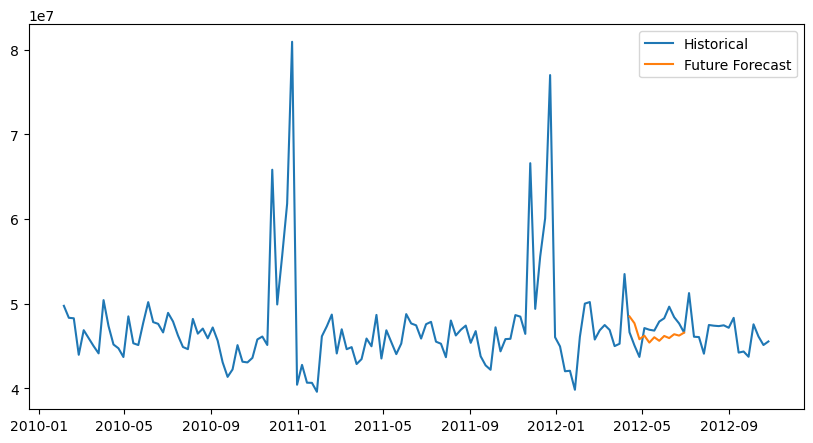

In [254]:
plt.figure(figsize=(10,5))
plt.plot(sales, label="Historical")
plt.plot(future, label="Future Forecast")
plt.legend()
plt.show()

# Forecasting using SARIMA

In [255]:
#pip install pmdarima

# Rolling mean visualization:

<Axes: xlabel='Date'>

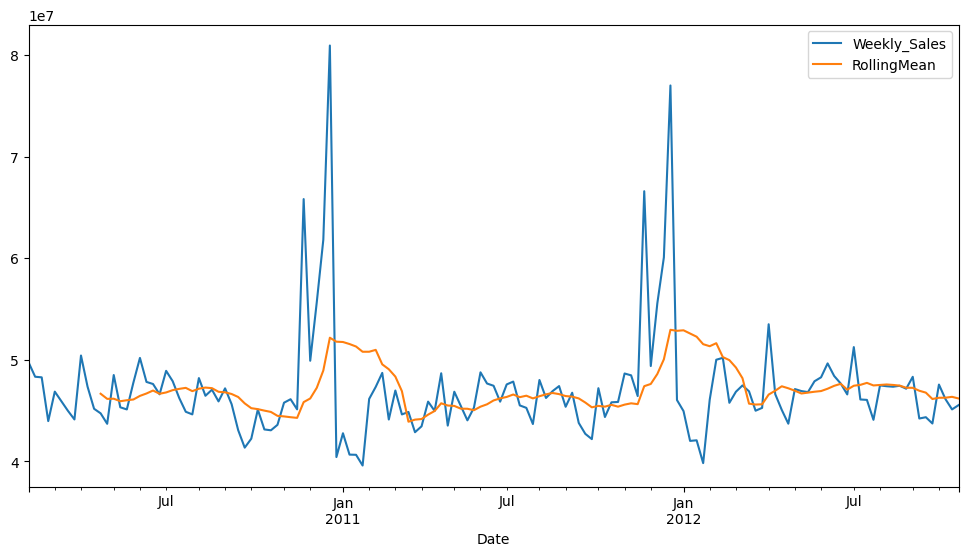

In [256]:
sales['RollingMean'] = sales['Weekly_Sales'].rolling(window=12).mean()
sales[['Weekly_Sales','RollingMean']].plot(figsize=(12,6))

# Feature Engineering (Lag Features)

In [257]:
sales['lag_1'] = sales['Weekly_Sales'].shift(1)
sales['lag_2'] = sales['Weekly_Sales'].shift(2)
sales['lag_3'] = sales['Weekly_Sales'].shift(3)
sales.dropna(inplace=True)

# auto_arima

In [258]:
from pmdarima import auto_arima
model = auto_arima(train,
                   seasonal=True,
                   m=12,
                   trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=1.42 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=3886.294, Time=0.03 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=3876.056, Time=0.31 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=3879.931, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=4356.186, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=3874.370, Time=0.04 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=3875.879, Time=0.11 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=1.06 sec
 ARIMA(2,0,0)(0,0,0)[12] intercept   : AIC=3874.673, Time=0.06 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=3875.637, Time=0.06 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=3878.644, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[12] intercept   : AIC=3876.666, Time=0.14 sec
 ARIMA(1,0,0)(0,0,0)[12]             : AIC=inf, Time=0.03 sec

Best model:  ARIMA(1,0,0)(0,0,0)[12] intercept
Total fit time: 3.450 seconds


# SARIMAX

In [259]:
model = SARIMAX(train['Weekly_Sales'],
                order=(3,0,2),
                seasonal_order=(0,0,0,12))
result = model.fit()
forecast = result.forecast(steps=len(test))

# FORECAST

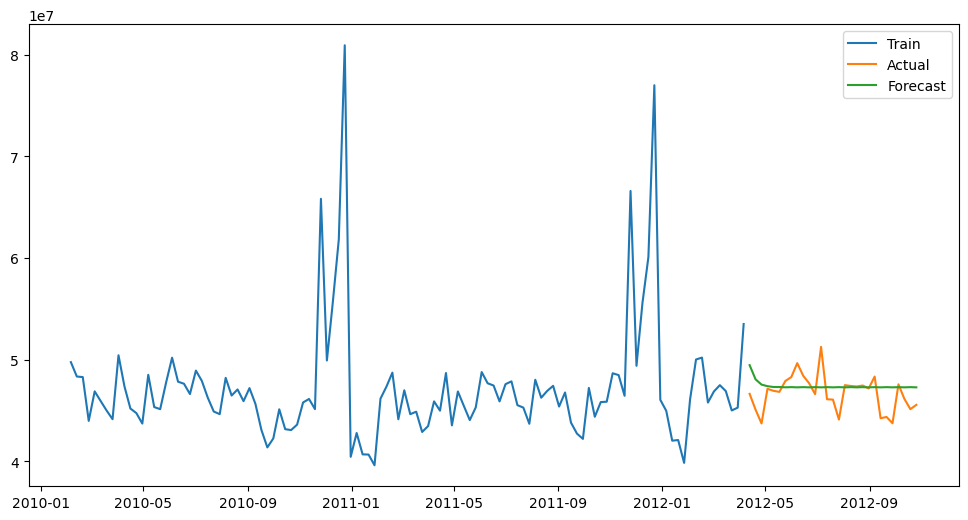

In [260]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train['Weekly_Sales'], label='Train')
plt.plot(test.index, test['Weekly_Sales'], label='Actual')
plt.plot(test.index, forecast, label='Forecast')
plt.legend()
plt.show()

# Model Evaluation

In [261]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
y_true = test['Weekly_Sales']
y_pred = forecast
mape = mean_absolute_percentage_error(y_true, y_pred)
print("MAPE:", mape*100)
print("MAE:", mae)
print("RMSE:", rmse)

MAPE: 3.228185738954301
MAE: 1485274.2502554958
RMSE: 1951094.8243009693


# Forecast Future Sales

In [262]:
future_sales = model_fit.forecast(steps=12)
print(future)

2012-04-13    4.850023e+07
2012-04-20    4.769358e+07
2012-04-27    4.580799e+07
2012-05-04    4.622683e+07
2012-05-11    4.540891e+07
2012-05-18    4.604039e+07
2012-05-25    4.562105e+07
2012-06-01    4.619086e+07
2012-06-08    4.594213e+07
2012-06-15    4.639705e+07
2012-06-22    4.623466e+07
2012-06-29    4.658250e+07
Freq: W-FRI, Name: predicted_mean, dtype: float64


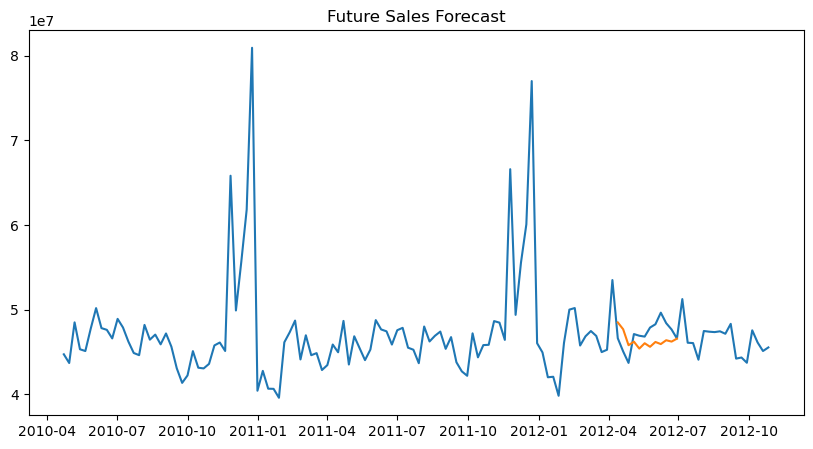

In [263]:
plt.figure(figsize=(10,5))
plt.plot(sales.index, sales['Weekly_Sales'])
plt.plot(future_sales.index, future_sales)
plt.title("Future Sales Forecast")
plt.show()

## SARIMAX modeL With exogenous variables

In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import mean_absolute_percentage_error
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [151]:
train= pd.read_csv(r'C:\Users\anupa\Desktop\Python Learning\Forecasting\train.csv')
features = pd.read_csv(r"C:\Users\anupa\Desktop\Python Learning\Forecasting\features.csv")
stores = pd.read_csv(r"C:\Users\anupa\Desktop\Python Learning\Forecasting\stores.csv")

In [152]:
import numpy as np
percentiles = np.arange(0, 1.05, 0.05)
distribution = train["Weekly_Sales"].quantile(percentiles)
print(distribution)

0.00     -4988.9400
0.05        59.9745
0.10       291.0970
0.15       727.3000
0.20      1340.9800
0.25      2079.6500
0.30      2913.3810
0.35      3843.1830
0.40      4887.9600
0.45      6152.9025
0.50      7612.0300
0.55      9271.7585
0.60     11274.6320
0.65     13679.9195
0.70     16619.3250
0.75     20205.8525
0.80     25217.6120
0.85     32481.0620
0.90     42845.6730
0.95     61201.9510
1.00    693099.3600
Name: Weekly_Sales, dtype: float64


In [153]:
train = train[train["Weekly_Sales"] > 100]

# Merge datasets

In [154]:
df = train.merge(features, on=["Store", "Date", "IsHoliday"])
df = df.merge(stores, on="Store")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.head()




,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
195796,21,54,2010-02-05,310.00,False,39.05,2.572,NaN,NaN,NaN,NaN,NaN,210.752605,8.324,B,140167
267304,29,9,2010-02-05,4419.73,False,24.36,2.788,NaN,NaN,NaN,NaN,NaN,131.527903,10.064,B,93638
195856,21,55,2010-02-05,10500.20,False,39.05,2.572,NaN,NaN,NaN,NaN,NaN,210.752605,8.324,B,140167
28344,3,97,2010-02-05,175.92,False,45.71,2.572,NaN,NaN,NaN,NaN,NaN,214.424881,7.368,B,37392


## Holiday Encoding

In [155]:
df["IsHoliday"] = df["IsHoliday"].astype(int)
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,0,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
195796,21,54,2010-02-05,310.00,0,39.05,2.572,NaN,NaN,NaN,NaN,NaN,210.752605,8.324,B,140167
267304,29,9,2010-02-05,4419.73,0,24.36,2.788,NaN,NaN,NaN,NaN,NaN,131.527903,10.064,B,93638
195856,21,55,2010-02-05,10500.20,0,39.05,2.572,NaN,NaN,NaN,NaN,NaN,210.752605,8.324,B,140167
28344,3,97,2010-02-05,175.92,0,45.71,2.572,NaN,NaN,NaN,NaN,NaN,214.424881,7.368,B,37392


# Aggregate Weekly Sales

In [156]:
#For simplicity we forecast total weekly sales.
sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
sales = sales.set_index('Date')

# Type Variable Encoding

In [157]:
df = pd.get_dummies(df, columns=["Type"], drop_first=True)


In [158]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size,Type_B,Type_C
0,1,1,2010-02-05,24924.50,0,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,151315,False,False
195796,21,54,2010-02-05,310.00,0,39.05,2.572,NaN,NaN,NaN,NaN,NaN,210.752605,8.324,140167,True,False
267304,29,9,2010-02-05,4419.73,0,24.36,2.788,NaN,NaN,NaN,NaN,NaN,131.527903,10.064,93638,True,False
195856,21,55,2010-02-05,10500.20,0,39.05,2.572,NaN,NaN,NaN,NaN,NaN,210.752605,8.324,140167,True,False
28344,3,97,2010-02-05,175.92,0,45.71,2.572,NaN,NaN,NaN,NaN,NaN,214.424881,7.368,37392,True,False


# Changing Type varibale to int

In [159]:
df["Type_B"] = df["Type_B"].astype(int)
df["Type_C"] = df["Type_C"].astype(int)

In [160]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size,Type_B,Type_C
0,1,1,2010-02-05,24924.50,0,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,151315,0,0
195796,21,54,2010-02-05,310.00,0,39.05,2.572,NaN,NaN,NaN,NaN,NaN,210.752605,8.324,140167,1,0
267304,29,9,2010-02-05,4419.73,0,24.36,2.788,NaN,NaN,NaN,NaN,NaN,131.527903,10.064,93638,1,0
195856,21,55,2010-02-05,10500.20,0,39.05,2.572,NaN,NaN,NaN,NaN,NaN,210.752605,8.324,140167,1,0
28344,3,97,2010-02-05,175.92,0,45.71,2.572,NaN,NaN,NaN,NaN,NaN,214.424881,7.368,37392,1,0


# Add Exogenous Variables

In [161]:
exog = df.groupby('Date')[['Temperature','Fuel_Price','CPI','Unemployment',"IsHoliday","Size","Type_B","Type_C"]].mean()

# Train Test Split

In [162]:
train_size = int(len(sales)*0.8)
train_sales = sales[:train_size]
test_sales = sales[train_size:]
train_exog = exog[:train_size]
test_exog = exog[train_size:]

# Build SARIMAX Model

In [163]:
model = SARIMAX(train_sales,
                exog=train_exog,
                order=(3,0,2),
                seasonal_order=(0,0,0,12))
results = model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                  114
Model:               SARIMAX(3, 0, 2)   Log Likelihood               -1918.255
Date:                Thu, 12 Mar 2026   AIC                           3864.509
Time:                        19:19:20   BIC                           3902.816
Sample:                    02-05-2010   HQIC                          3880.056
                         - 04-06-2012                                         
Covariance Type:                  opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Temperature  -5573.8888   4.04e+04     -0.138      0.890   -8.48e+04    7.37e+04
Fuel_Price   -3.716e+06   1.48e+04   -251.307      0.000   -3.74e+06   -3.69e+06
CPI           2.383e+06   8.31e+04     28.67

In [164]:
forecast = results.predict(start=len(train_sales),
                           end=len(sales)-1,
                           exog=test_exog)

# Plot Forecast vs Actual

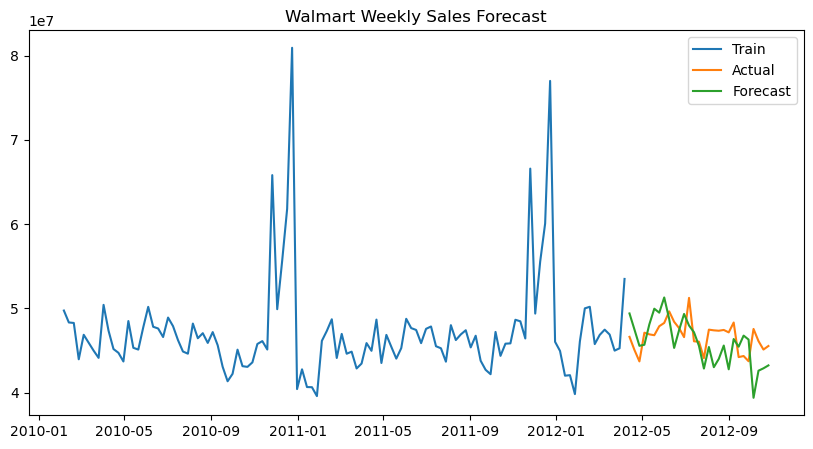

In [165]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(train_sales, label="Train")
plt.plot(test_sales, label="Actual")
plt.plot(forecast, label="Forecast")
plt.legend()
plt.title("Walmart Weekly Sales Forecast")
plt.show()

# Evaluate Forecast

In [166]:
mae = mean_absolute_error(test_sales, forecast)
rmse = np.sqrt(mean_squared_error(test_sales, forecast))
y_true = test_sales['Weekly_Sales']
y_pred = forecast
mape = mean_absolute_percentage_error(y_true, y_pred)
print("MAPE:", mape*100)
print("MAE:", mae)
print("RMSE:", rmse)

MAPE: 5.222797123653322
MAE: 2445195.762007369
RMSE: 2865191.49492597


## Machine learning Models

In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import mean_absolute_percentage_error
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [168]:
train= pd.read_csv(r'C:\Users\anupa\Desktop\Python Learning\Forecasting\train.csv')
features = pd.read_csv(r"C:\Users\anupa\Desktop\Python Learning\Forecasting\features.csv")
stores = pd.read_csv(r"C:\Users\anupa\Desktop\Python Learning\Forecasting\stores.csv")

# Keep Only Positive Sales

In [169]:
train = train[train["Weekly_Sales"] > 100]
train = train.reset_index(drop=True)

# Convert Date

In [170]:
train["Date"] = pd.to_datetime(train["Date"])
features["Date"] = pd.to_datetime(features["Date"])

# Merge Datasets

In [171]:
df = train.merge(features, on=["Store","Date","IsHoliday"], how="left")
df = df.merge(stores, on="Store", how="left")

# Holiday Encoding

In [172]:
df["IsHoliday"] = df["IsHoliday"].astype(int)

# Create Time Features and sort data

In [173]:
df["month"] = df["Date"].dt.month
df["week"] = df["Date"].dt.isocalendar().week.astype(int)
df["year"] = df["Date"].dt.year
df = df.sort_values(["Store","Dept","Date"])

# Create Lag Features

In [174]:
df["lag_1"] = df.groupby(["Store","Dept"])["Weekly_Sales"].shift(1)
df["lag_2"] = df.groupby(["Store","Dept"])["Weekly_Sales"].shift(2)
df["lag_3"] = df.groupby(["Store","Dept"])["Weekly_Sales"].shift(3)

# Create Rolling Features

In [175]:
df["rolling_mean_4"] = df.groupby(["Store","Dept"])["Weekly_Sales"].shift(1).rolling(4).mean()
df["rolling_std_4"] = df.groupby(["Store","Dept"])["Weekly_Sales"].shift(1).rolling(4).std()

# Encode Store Type

In [176]:
df = pd.get_dummies(df, columns=["Type"], drop_first=True)

# Remove Missing Values

In [177]:
df = df.dropna()

# Define Features

In [178]:
features_cols = [
"Store",
"Dept",
"IsHoliday",
"Temperature",
"Fuel_Price",
"CPI",
"Unemployment",
"Size",
"month",
"week",
"year",
"lag_1",
"lag_2",
"lag_3",
"rolling_mean_4",
"rolling_std_4",
"Type_B",
"Type_C"
]

X = df[features_cols]
y = df["Weekly_Sales"]

# Train-Test Split (Time Based)

In [179]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

# Random Forest Model

In [180]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# XGBoost Model

In [181]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [182]:
print(y_test.describe())

count     18583.000000
mean      17125.628981
std       21791.055250
min         100.010000
25%        3096.280000
50%        8817.000000
75%       21990.920000
max      351553.980000
Name: Weekly_Sales, dtype: float64


# Model Evaluation

In [183]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mape = mean_absolute_percentage_error(y_test, rf_pred) * 100

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mape = mean_absolute_percentage_error(y_test, xgb_pred) * 100

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("MAPE:", rf_mape)

print("\nXGBoost")
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("MAPE:", xgb_mape)



Random Forest
MAE: 2063.5616408559854
RMSE: 5403.1800010930865
MAPE: 21.250613845346198

XGBoost
MAE: 1676.5457008510602
RMSE: 3653.9462372801117
MAPE: 23.604749468909045


# Plot Forecast

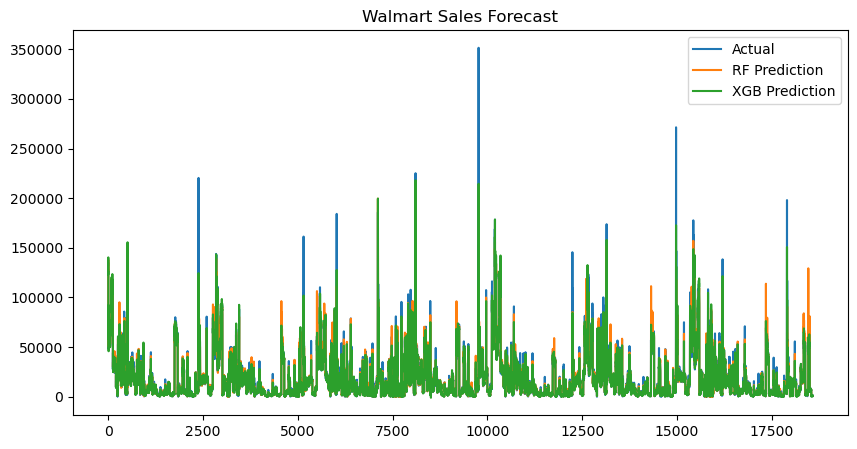

In [184]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values, label="Actual")
plt.plot(rf_pred, label="RF Prediction")
plt.plot(xgb_pred, label="XGB Prediction")

plt.legend()
plt.title("Walmart Sales Forecast")
plt.show()